<a href="https://colab.research.google.com/github/vignesh156-byte/ds_vignesh/blob/main/Aerial_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:


import os

dataset_path = "/content/drive/MyDrive/aerial sample data"

for root, dirs, files in os.walk(dataset_path):
    print(f"Folder: {root}")
    print(f"Subfolders: {dirs}")
    print(f"Number of files: {len(files)}\n")

Folder: /content/drive/MyDrive/aerial sample data
Subfolders: ['test', 'train', 'valid']
Number of files: 3

Folder: /content/drive/MyDrive/aerial sample data/test
Subfolders: ['bird', 'drone']
Number of files: 0

Folder: /content/drive/MyDrive/aerial sample data/test/bird
Subfolders: []
Number of files: 121

Folder: /content/drive/MyDrive/aerial sample data/test/drone
Subfolders: []
Number of files: 94

Folder: /content/drive/MyDrive/aerial sample data/train
Subfolders: ['drone', 'bird']
Number of files: 0

Folder: /content/drive/MyDrive/aerial sample data/train/drone
Subfolders: []
Number of files: 1248

Folder: /content/drive/MyDrive/aerial sample data/train/bird
Subfolders: []
Number of files: 1414

Folder: /content/drive/MyDrive/aerial sample data/valid
Subfolders: ['bird', 'drone']
Number of files: 0

Folder: /content/drive/MyDrive/aerial sample data/valid/bird
Subfolders: []
Number of files: 217

Folder: /content/drive/MyDrive/aerial sample data/valid/drone
Subfolders: []
Number

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

def preprocess_image(dataset_path):
    # 1. Read image file
    image = tf.io.read_file(dataset_path)

    # 2. Decode (JPEG/PNG)
    image = tf.image.decode_jpeg(image, channels=3)

    # 3. Resize
    image = tf.image.resize(image, (224, 224))

    # 4. Normalize
    image = tf.cast(image, tf.float32) / 255.0

    return image


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/aerial sample data"))

['test-20260417T090253Z-3-001.zip', 'train-20260417T090335Z-3-001.zip', 'valid-20260417T090800Z-3-001.zip', 'test', 'train', 'valid']


In [ ]:
if not os.path.exists(base_path + "/train"):
    base_path=!unzip -q "/content/drive/MyDrive/aerial sample data/*.zip" -d

In [ ]:
import zipfile
import os

base_path = "/content/drive/MyDrive/aerial sample data"

zip_files = [f for f in os.listdir(base_path) if f.endswith(".zip")]

for zip_file in zip_files:
    with zipfile.ZipFile(os.path.join(base_path, zip_file), 'r') as z:
        z.extractall(base_path)

print("Done ✅")

Done ✅


In [ ]:
import tensorflow as tf

dataset = tf.keras.utils.image_dataset_from_directory(
    base_path,
    image_size=(224,224),
    batch_size=32
)


Found 3319 files belonging to 3 classes.


In [ ]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/aerial sample data/train",
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/aerial sample data/valid",
    image_size=(224,224),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/aerial sample data/test",
    image_size=(224,224),
    batch_size=32
)

Found 2662 files belonging to 2 classes.
Found 442 files belonging to 2 classes.
Found 215 files belonging to 2 classes.


In [ ]:
class_names = train_ds.class_names
print("Classes:", class_names)

Classes: ['bird', 'drone']


In [ ]:
import numpy as np

class_counts = {name: 0 for name in class_names}

for images, labels in train_ds:
    for label in labels:
        class_counts[class_names[label.numpy()]] += 1

print(class_counts)

{'bird': 1414, 'drone': 1248}


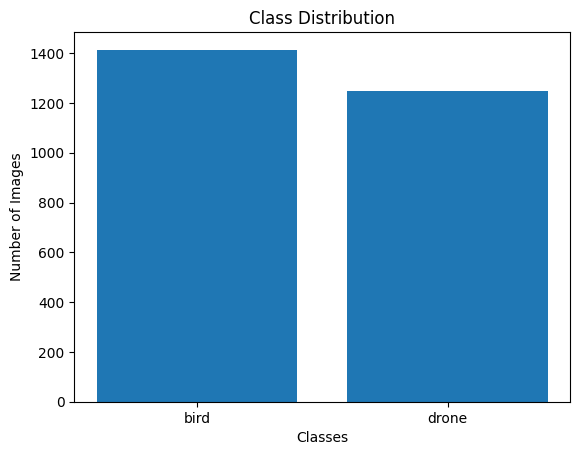

In [ ]:
import matplotlib.pyplot as plt

plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.show()

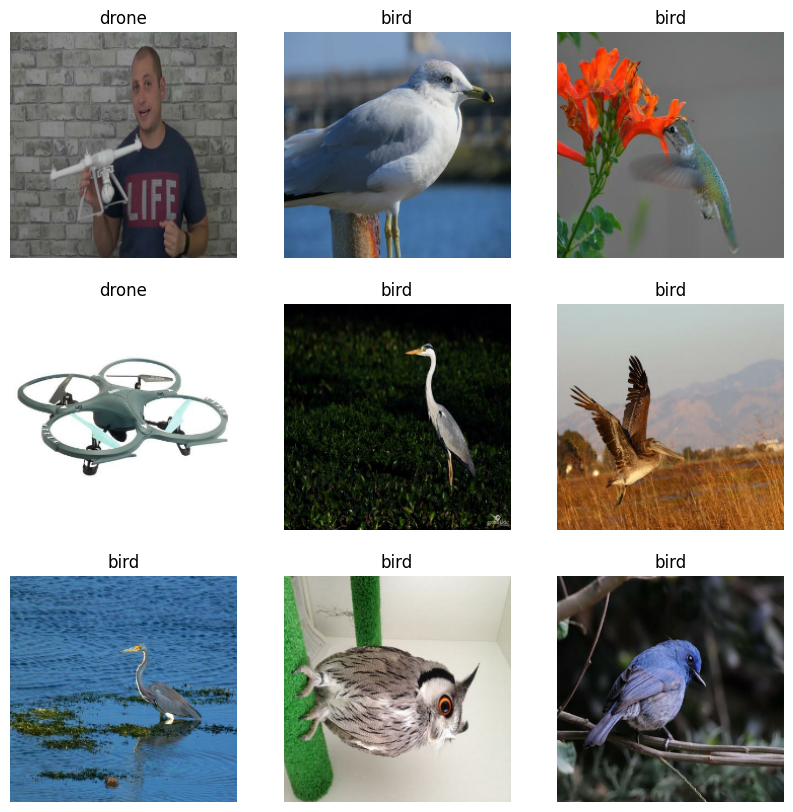

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [ ]:
from tensorflow.keras import layers

normalization_layer = layers.Rescaling(1./255)

In [ ]:
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),          # flipping
    layers.RandomRotation(0.1),               # rotation (~±10%)
    layers.RandomZoom(0.1),                   # zoom
    layers.RandomContrast(0.1),               # brightness/contrast
    layers.RandomTranslation(0.1, 0.1),       # slight cropping/shift
])

In [ ]:
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds   = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds  = test_ds.map(lambda x, y: (preprocess_input(x), y))

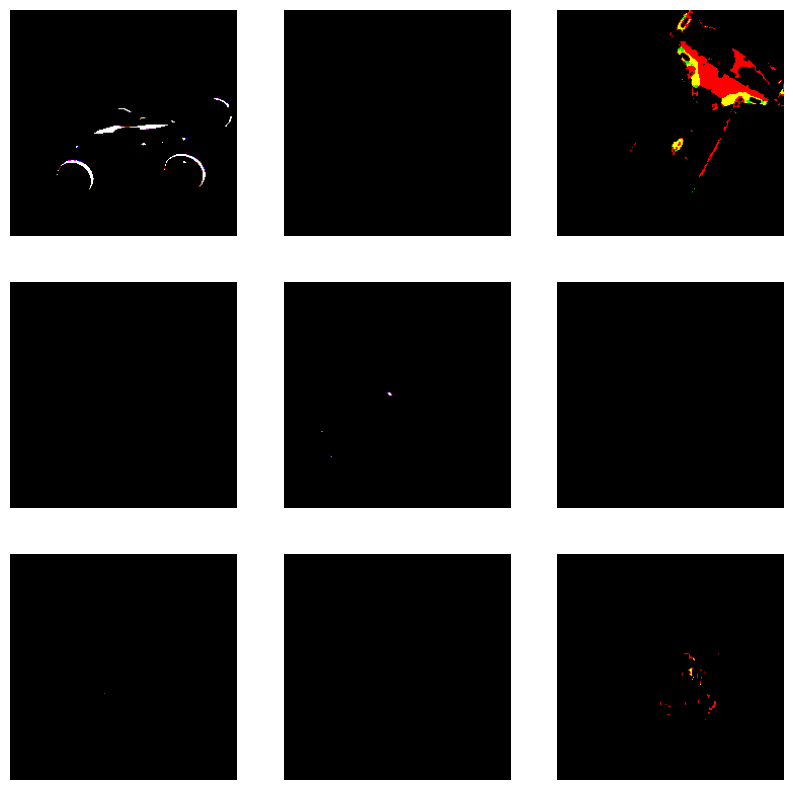

In [ ]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10,10))
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")
    plt.show()

In [ ]:
import numpy as np

x_test = []
y_test = []

for images, labels in test_ds:
    x_test.append(images.numpy())
    y_test.append(labels.numpy())

x_test = np.concatenate(x_test)
y_test = np.concatenate(y_test)

In [ ]:
# Define a CNN Model
    #keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),  # Conv Layer 1
model = tf.keras.Sequential([
    layers.Input(shape=(224,224,3)),   # ✅ correct way
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.Conv2D(32, (3,3), activation='relu'),
    keras.layers.Conv2D(64, (4, 4), activation='relu', input_shape=(28, 28, 1)),# Conv Layer 1
    keras.layers.MaxPooling2D((3, 3)),  # Pooling Layer 1
    keras.layers.MaxPooling2D((3, 3)),  # Pooling Layer 1

    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.Conv2D(32, (3, 3), activation='relu'),# Conv Layer 2
    keras.layers.MaxPooling2D((2, 2)), # Pooling Layer 2

    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.Conv2D(32, (3, 3), activation='relu'),# Conv Layer 3
    keras.layers.MaxPooling2D((2, 2)),  # Pooling Layer 3



    keras.layers.Flatten(),  # Flatten Feature Maps
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(64,activation='softmax'),# Fully Connected Layer
    keras.layers.Dense(15, activation='softmax')  # Output Layer (10 classes)
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)
predictions = model.predict(test_ds)
model.evaluate(test_ds)

# Show the first test image and its predicted label
plt.imshow(x_test[10].reshape(28, 28), cmap='gray')
plt.title(f"Predicted Label: {np.argmax(predictions[0])}")
plt.axis('off')
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
 4/84 ━━━━━━━━━━━━━━━━━━━━ 21:04 16s/step - accuracy: 0.4167 - loss: 2.6896

KeyboardInterrupt: 

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(300, activation='relu')(x)
output = tf.keras.layers.Dense(5, activation='softmax')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.5492 - loss: 0.7168 - val_accuracy: 0.5339 - val_loss: 0.6496
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.6191 - loss: 0.6560 - val_accuracy: 0.5090 - val_loss: 0.7598
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.6191 - loss: 0.6905 - val_accuracy: 0.7104 - val_loss: 0.5846
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.6702 - loss: 0.6077 - val_accuracy: 0.7014 - val_loss: 0.5875
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.6653 - loss: 0.6048 - val_accuracy: 0.7014 - val_loss: 0.5567
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.6807 - loss: 0.5905 - val_accuracy: 0.7330 - val_loss: 0.5376
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.6829 - loss: 0.5811 - val_accuracy: 0.6109 - val_loss: 0.7533
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import os

IMG_SIZE = 224
BATCH_SIZE = 32


transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder("/content/drive/MyDrive/aerial sample data/train", transform=transform)
val_data   = datasets.ImageFolder("/content/drive/MyDrive/aerial sample data/valid", transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_data.classes
print(class_names)

['bird', 'drone']


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
def train_model(model, train_loader, val_loader, epochs, model_name):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

    best_acc = 0.0

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total
        train_loss = running_loss / len(train_loader)

        # 🔹 Validation
        model.eval()
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                _, predicted = torch.max(outputs, 1)

                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total

        print(f"{model_name} | Epoch [{epoch+1}/{epochs}] "
              f"Loss: {train_loss:.4f} "
              f"Train Acc: {train_acc:.4f} "
              f"Val Acc: {val_acc:.4f}")

        # ✅ Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f"{model_name}_best.pth")

    print(f"Best Val Accuracy for {model_name}: {best_acc:.4f}")

In [ ]:
def get_vgg16():
    model = models.vgg16(pretrained=True)

    # Freeze feature layers
    for param in model.features.parameters():
        param.requires_grad = False

    # Replace classifier
    model.classifier[6] = nn.Linear(4096, 2)

    return model


In [ ]:
vgg_model = get_vgg16()
train_model(vgg_model, train_loader, val_loader, epochs=5, model_name="vgg16")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 90.0MB/s]


vgg16 | Epoch [1/5] Loss: 0.1332 Train Acc: 0.9425 Val Acc: 0.9751
vgg16 | Epoch [2/5] Loss: 0.0135 Train Acc: 0.9951 Val Acc: 0.9683
vgg16 | Epoch [3/5] Loss: 0.0021 Train Acc: 1.0000 Val Acc: 0.9751
vgg16 | Epoch [4/5] Loss: 0.0006 Train Acc: 1.0000 Val Acc: 0.9774
vgg16 | Epoch [5/5] Loss: 0.0004 Train Acc: 1.0000 Val Acc: 0.9706
Best Val Accuracy for vgg16: 0.9774


In [ ]:
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_model = vgg_model.to(device)
y_true = []
y_pred = []

vgg_model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)   # ✅ FIX
        labels = labels.to(device)   # (optional but good)

        outputs = vgg_model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        accuracy = np.mean(np.array(y_true) == np.array(y_pred))
print(f"Accuracy: {accuracy*100:.2f}%")

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_true, y_pred))


print(classification_report(y_true, y_pred))

Accuracy: 97.06%

Confusion Matrix:

[[210   7]
 [  6 219]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       217
           1       0.97      0.97      0.97       225

    accuracy                           0.97       442
   macro avg       0.97      0.97      0.97       442
weighted avg       0.97      0.97      0.97       442



In [ ]:
import torch

torch.save(vgg_model.state_dict(), "vgg16_model.pth")
print("Model saved ✅")

Model saved ✅


In [ ]:
from google.colab import files

files.download("vgg16_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>